
# TRNG Approach A - RTC vs TCC Jitter on XMEGA (CW303)
Quick testbench to compile, flash, collect, and evaluate random bits from a
TRUERA-style TRNG adapted to the ATxmega128D4 on ChipWhisperer CW303.

> Duplicate this notebook to create Approach B/C/D (e.g., ADC noise, ring oscillators, SRAM startup), changing only the acquisition cell title & acquisition code. Each notebook keeps the same test battery, so you can compare results apples-to-apples.



## Requirements
- ChipWhisperer installed (`pip install chipwhisperer`), hardware connected (CW-Lite/NAE-Scope + CW303 XMEGA target).
- Your TRNG firmware placed in `FW_DIR` (below) and builds with `make PLATFORM=CW303` to create `.hex`.
- The firmware implements SimpleSerial command: `r<N>` -> returns `ceil(N/8)` bytes (MSB-first packing).

If you use my minimal no-FIFO firmware from chat, you're good.


## 1) Build firmware

In [153]:
import chipwhisperer as cw
import numpy as np
import matplotlib.pyplot as plt
from tqdm.notebook import trange

scope = cw.scope()
target = cw.target(scope, cw.targets.SimpleSerial2)
scope.default_setup()

scope.gain.mode                          changed from low                       to high                     
scope.gain.gain                          changed from 0                         to 30                       
scope.gain.db                            changed from 5.5                       to 24.8359375               
scope.adc.basic_mode                     changed from low                       to rising_edge              
scope.adc.samples                        changed from 24400                     to 5000                     
scope.adc.trig_count                     changed from 16923970                  to 45005032                 
scope.clock.adc_src                      changed from clkgen_x1                 to clkgen_x4                
scope.clock.adc_freq                     changed from 96000000                  to 29538471                 
scope.clock.adc_rate                     changed from 96000000.0                to 29538471.0               
scope.clock.clkgen_

In [ ]:
%%bash
make PLATFORM=CWLITEXMEGA SOURCE=temp_sen_mix.c SS_VER=SS_VER_2_1

No CRYPTO_TARGET passed - defaulting to TINYAES128C
Building for platform CWLITEXMEGA with CRYPTO_TARGET=TINYAES128C
SS_VER set to SS_VER_2_1
SS_VER set to SS_VER_2_1
Blank crypto options, building for AES128
.
Welcome to another exciting ChipWhisperer target build!!
avr-gcc (GCC) 7.3.0
Copyright (C) 2017 Free Software Foundation, Inc.
This is free software; see the source for copying conditions.  There is NO
warranty; not even for MERCHANTABILITY or FITNESS FOR A PARTICULAR PURPOSE.

mkdir -p objdir-CWLITEXMEGA 
.
Compiling:
-en     temp_sen.c ...
-e Done!
.
Compiling:
-en     ../../../firmware/mcu/simpleserial/simpleserial.c ...
-e Done!
.
Compiling:
-en     ../../../firmware/mcu/hal/hal.c ...
-e Done!
.
Compiling:
-en     ../../../firmware/mcu/hal//xmega/XMEGA_AES_driver.c ...
-e Done!
.
Compiling:
-en     ../../../firmware/mcu/hal//xmega/uart.c ...
-e Done!
.
Compiling:
-en     ../../../firmware/mcu/hal//xmega/usart_driver.c ...
-e Done!
.
Compiling:
-en     ../../../firmware/mcu/h

## 2) Program target (XMEGA on CW303)

In [498]:
hex = "output-CWLITEXMEGA.hex"
cw.program_target(scope, cw.programmers.XMEGAProgrammer, hex)

XMEGA Programming flash...
XMEGA Reading flash...
Verified flash OK, 4547 bytes


## 3) Acquire random bits - Approach A: RTC vs TCC jitter

In [517]:
target.flush()

# Ask target for that chunk
target.simpleserial_write('c', b'')

# Read exactly 'want' bytes (no ack check until final)
random_bytes = target.simpleserial_read('r', 1)
print(random_bytes)  # Should be N bytes

CWbytearray(b'89')


I asked the target to give me the bytes in chunks of 249 (using simpleserial_read) and not with bigger ones because i dont want to overflow the USB buffer because the throuput of this TRNG is very fast

In [522]:
target.flush()
# Encode "want" as a 2-byte little-endian payload
N = 40
payload = N.to_bytes(1, 'little')

# Ask target for that chunk
target.simpleserial_write('b', payload)

# Read exactly 'want' bytes (no ack check until final)
random_bytes = target.simpleserial_read('r', N, timeout=200000)
print(random_bytes)  # Should be N bytes

CWbytearray(b'97 76 61 18 88 82 20 02 20 00 02 21 11 12 2e ed d4 43 32 2f f0 07 73 3d db ba a5 51 19 99 9d d0 0e e8 8f fa aa a9 95 5a')


In [172]:


N = 200        # total bytes you want
CHUNK = 249            # safe per-request size
buf = bytearray()

# Loop until we have N bytes
remaining = N
while remaining > 0:
    target.flush()
    want = min(CHUNK, remaining)

    # Encode "want" as a 2-byte little-endian payload
    payload = want.to_bytes(2, 'little')

    # Ask target for that chunk
    target.simpleserial_write('b', payload)

    # Read exactly 'want' bytes (no ack check until final)
    chunk = target.simpleserial_read('r', want, timeout=200000, ack=False )
    if chunk is None:
        raise RuntimeError("Timeout waiting for target")

    buf.extend(chunk)
    remaining -= want


print("Data length:", len(buf))
print("First 32 bytes:", buf[:32])


(ChipWhisperer Target WARNING|File SimpleSerial2.py:512) Unexpected frame byte in CWbytearray(b'03 72 c8 01 01 01 01 01 01 01 01 01 01 01 01 01 01 01 01 b9 b0 d6 5a 6b ad b5 d6 5a 6b ad b5 d6 5a 6b ad b5 d6 5a 6b ad b5 ce 39 e7 9c 73 ce 39 e7 9c 73 ce 39 e7 9c 73 ce 39 e7 9c 73 10 42 08 21 84 10 42 08 21 84 10 42 08 21 84 10 42 08 21 84 d0 18 63 8c 31 c6 18 63 8c 31 c6 18 63 8c 31 c6 18 63 8c 31 c6 d8 7b ef bd f7 de 7b ef bd f7 de 7b ef bd f7 de 7b ef bd f7 16 42 08 21 84 10 42 08 21 84 10 42 08 21 84 10 42 08 21 84 10 39 e7 9c 73 ce 39 e7 9c 73 ce 39 e7 9c 73 ce 39 e7 9c 73 ce 59 08 21 84 10 42 08 21 84 10 42 08 21 84 10 42 08 21 84 10 42 08 21 84 10 42 08 21 84 10 42 08 21 84 10 42 21 84 10 c9 00 03')


RuntimeError: Timeout waiting for target

## senity check

In [557]:
import numpy as np
import matplotlib.pyplot as plt
import time

target.flush()


N = 200               # total bytes you want
CHUNK = 200             # safe per-request size
buf = bytearray()

remaining = N
while remaining > 0:
    want = min(CHUNK, remaining)

    # encode request size
    payload = want.to_bytes(2, 'little')
    target.simpleserial_write('b', payload)

    # read with timeout & retry protection
    got = 0
    retries = 0
    while got < want:
        chunk = target.simpleserial_read('r', want - got, timeout=2000000)
        if chunk is None or len(chunk) == 0:
            retries += 1
            if retries > 5:
                print(f"Discarding incomplete block ({got}/{want})")
                break
            continue

        buf.extend(chunk)
        got += len(chunk)

    remaining -= got
    time.sleep(0.01)  # small gap between blocks

print("Collected:", len(buf), "bytes")

# ---------- Analysis ----------
data = np.frombuffer(buf, dtype=np.uint8)

# Bit biases
biases = []
for b in range(8):
    ones = np.count_nonzero((data >> b) & 1)
    p1 = ones / len(data)
    biases.append(p1)
    print(f"bit {b}: p1={p1:.5f}")

plt.figure(figsize=(7,4))
plt.bar(range(8), biases, color="royalblue")
plt.axhline(0.5, color="red", linestyle="--", label="ideal=0.5")
plt.xticks(range(8), [f"bit {i}" for i in range(8)])
plt.ylabel("Probability of 1")
plt.title(f"Bit bias per position (from {len(data)} bytes)")
plt.legend()
plt.show()

# Byte distribution
values, counts = np.unique(data, return_counts=True)
probs = counts / len(data)

print("\nByte distribution stats:")
print(f"Min prob: {probs.min():.4f}, Max prob: {probs.max():.4f}, Expected={1/256:.4f}")

plt.hist(data, bins=256, range=(0, 255), density=True, color='skyblue')
plt.axhline(1/256, color='r', linestyle='--', label="Uniform expected")
plt.xlabel("Byte value (0–255)")
plt.ylabel("Probability")
plt.title("Distribution of TRNG Byte Values")
plt.legend()
plt.show()


KeyboardInterrupt: 

In [ ]:
import numpy as np
import logging

# Silence ChipWhisperer "Target" warnings
logging.getLogger("ChipWhisperer Target").setLevel(logging.ERROR)

# Parameters
NUM_TESTS = 1000   # how many restart runs
BYTES_PER_SAMPLE = 125   # 1000 bits minimum
CHUNK = 200          # safe per-request size

all_samples = []

for i in range(NUM_TESTS):
    print(f"[{i+1}/{NUM_TESTS}] collecting...")

    buf = bytearray()
    remaining = BYTES_PER_SAMPLE

    while remaining > 0:
        want = min(CHUNK, remaining)
        payload = want.to_bytes(2, 'little')
        target.flush()   # reset UART buffers
        target.simpleserial_write('b', payload)

        chunk = target.simpleserial_read('r', want, timeout=2000)
        if chunk is None or len(chunk) != want:
            print("Bad block, skipping this sample...")
            continue

        buf.extend(chunk)
        remaining -= want

    # Store if successful
    if buf is not None:
        all_samples.append(np.frombuffer(buf, dtype=np.uint8))


# Save all samples into one .npy file
all_samples = np.array(all_samples, dtype=np.uint8)
np.save("data/temp_sen_2times_4bit_concat_10ms_delay/restart_test_samples_only_temp_sens_2_samples_4bit_concat.npy", all_samples)

print(f"Saved {len(all_samples)} samples to restart_test_samples.npy")


[1/1000] collecting...
[2/1000] collecting...
[3/1000] collecting...
[4/1000] collecting...
[5/1000] collecting...
[6/1000] collecting...
[7/1000] collecting...
[8/1000] collecting...
[9/1000] collecting...
[10/1000] collecting...
[11/1000] collecting...
[12/1000] collecting...
[13/1000] collecting...
[14/1000] collecting...
[15/1000] collecting...
[16/1000] collecting...
[17/1000] collecting...
[18/1000] collecting...
[19/1000] collecting...
[20/1000] collecting...
[21/1000] collecting...
[22/1000] collecting...
[23/1000] collecting...
[24/1000] collecting...
[25/1000] collecting...
[26/1000] collecting...
[27/1000] collecting...
[28/1000] collecting...
[29/1000] collecting...
[30/1000] collecting...
[31/1000] collecting...
[32/1000] collecting...
[33/1000] collecting...
[34/1000] collecting...
[35/1000] collecting...
[36/1000] collecting...
[37/1000] collecting...
[38/1000] collecting...
[39/1000] collecting...
[40/1000] collecting...
[41/1000] collecting...
[42/1000] collecting...
[

In [609]:
print(all_samples[0])

[161  18  39 125 213  93 212  69  94 237 215 116  72 140 202 162  32  12
 198 103 119 123 184 142 236 192   7 117  85  91 188 193  30 239 248 143
 244  76 197  84  72 129  17  18  47 252 193  29 219 190 231 127 254 230
 109 210  45 218 165  87 116  74 160   2  47 240   7 113  18  41 144  10
 173 223 250 161  16   9 151 114  44 192  11 188 197  93 211  61 212  78
 233 148  68  77 222 229  83  48  11 180  78 239 242  34  47 244  68  67
  50  36  75 176  14 239 248 130  47 254 235 179  51  50  42 160  13]


In [607]:
np.save("data/1m_bit_random_data_only_temp_sens_2_samples_4bit_concat.npy", data)


bit 0: p1=0.50042
bit 1: p1=0.50537
bit 2: p1=0.50446
bit 3: p1=0.49195
bit 4: p1=0.50046
bit 5: p1=0.50550
bit 6: p1=0.50458
bit 7: p1=0.49212


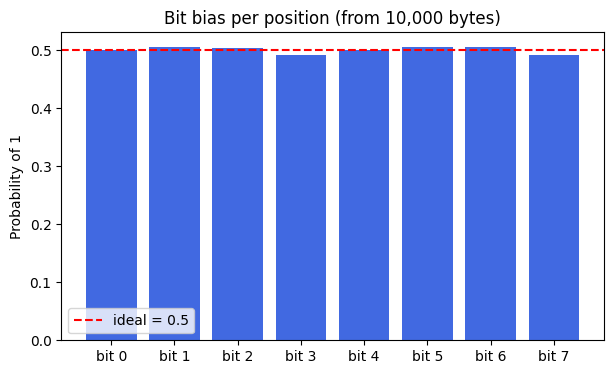


Byte distribution stats:
Min prob: 0.0015, Max prob: 0.0068, Expected = 0.0039


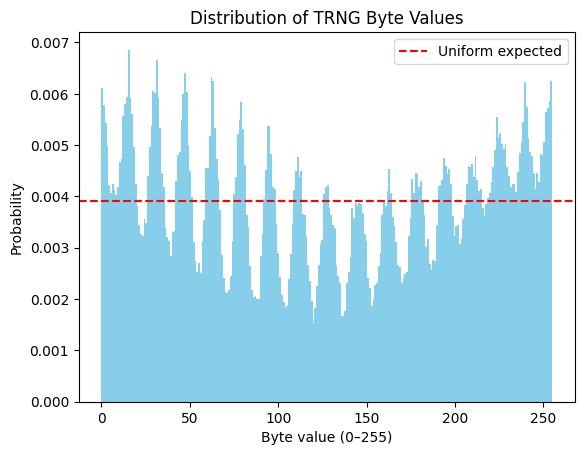

In [602]:
import numpy as np
import time
import logging   # <-- add this

# Silence ChipWhisperer "Target" warnings
logging.getLogger("ChipWhisperer Target").setLevel(logging.ERROR)

CHUNK = 100            # safe per-request size
I = 1250
N = I*CHUNK               # total bytes you want
buf = bytearray()

# Loop until we have N bytes
remaining = N
while remaining > 0:
    target.flush()
    want = min(CHUNK, remaining)

    # Encode "want" as a 2-byte little-endian payload
    payload = want.to_bytes(2, 'little')

    # Ask target for that chunk
    target.simpleserial_write('b', payload)

    # Read exactly 'want' bytes (no ack check until final)
    chunk = target.simpleserial_read('r', want, timeout=2000)
    if chunk is None or len(chunk) != want:
        print("Bad block, skipping…")
        continue
    # if chunk is None:
    #     raise RuntimeError("Timeout waiting for target")

    buf.extend(chunk)
    remaining -= want
    # time.sleep(1)   # 10 ms gap between chunks


# ---------- Analysis ----------
data = np.frombuffer(buf, dtype=np.uint8)
biases = []

for b in range(8):
    ones = np.count_nonzero((data >> b) & 1)
    p1 = ones / len(data)
    biases.append(p1)
    print(f"bit {b}: p1={p1:.5f}")

# ---------- Plot ----------
plt.figure(figsize=(7,4))
plt.bar(range(8), biases, color="royalblue")
plt.axhline(0.5, color="red", linestyle="--", label="ideal = 0.5")
plt.xticks(range(8), [f"bit {i}" for i in range(8)])
plt.ylabel("Probability of 1")
plt.title("Bit bias per position (from 10,000 bytes)")
plt.legend()
plt.show()


# ===== 3. Byte value distribution =====
values, counts = np.unique(data, return_counts=True)
probs = counts / len(data)

print("\nByte distribution stats:")
print(f"Min prob: {probs.min():.4f}, Max prob: {probs.max():.4f}, Expected = {1/256:.4f}")

plt.hist(data, bins=256, range=(0, 255), density=True, color='skyblue')
plt.axhline(1/256, color='r', linestyle='--', label="Uniform expected")
plt.xlabel("Byte value (0–255)")
plt.ylabel("Probability")
plt.title("Distribution of TRNG Byte Values")
plt.legend()
plt.show()

In [603]:
from scipy.stats import entropy

H = entropy(probs, base=2)
print(f"Shannon entropy: {H:.4f} bits per byte (ideal = 8)")


Shannon entropy: 7.9348 bits per byte (ideal = 8)


In [604]:
from scipy.stats import chisquare

# Build observed histogram (256 bins, one per possible byte value)
observed, _ = np.histogram(data, bins=256, range=(0, 256))

# Expected: uniform distribution with same total count
expected = np.full(256, len(data) / 256)

# Chi-square test
chi2, pval = chisquare(observed, expected)
print(f"Chi-square = {chi2:.2f}, p = {pval:.3e}")



Chi-square = 10993.82, p = 0.000e+00


In [605]:
# Convert bytes → bits
bits = np.unpackbits(data)

def autocorr(bits, lag):
    return np.corrcoef(bits[:-lag], bits[lag:])[0,1]

for lag in [1, 2, 4, 8, 16]:
    ac = autocorr(bits, lag)
    print(f"Autocorrelation lag {lag}: {ac:.5f}")


Autocorrelation lag 1: 0.05113
Autocorrelation lag 2: 0.03070
Autocorrelation lag 4: 0.48717
Autocorrelation lag 8: -0.01559
Autocorrelation lag 16: 0.00684


In [593]:
import numpy as np
from scipy.stats import chisquare

def poker_test(bits, m_values=[2,3,4,5,6,8]):
    N = len(bits)
    results = []
    for m in m_values:
        num_chunks = N // m
        if num_chunks < 50:
            continue  # not enough samples for this m

        # group into m-bit chunks
        chunks = np.packbits(bits[:num_chunks*m].reshape(-1, m), axis=-1, bitorder='little').flatten()
        freqs = np.bincount(chunks, minlength=2**m)

        # expected counts (uniform)
        expected = np.full(2**m, num_chunks / (2**m))
        chi2, pval = chisquare(freqs, expected)

        results.append((m, chi2, pval))

    return results



bits = np.unpackbits(data)  # turn your bytes into bitstream
results = poker_test(bits)

for m, chi2, pval in results:
    print(f"m={m}: Chi²={chi2:.2f}, p={pval:.3f}")



m=2: Chi²=1580.25, p=0.000
m=3: Chi²=748.19, p=0.000
m=4: Chi²=3711.17, p=0.000
m=5: Chi²=21063.70, p=0.000
m=6: Chi²=51308.97, p=0.000
m=8: Chi²=4913.54, p=0.000


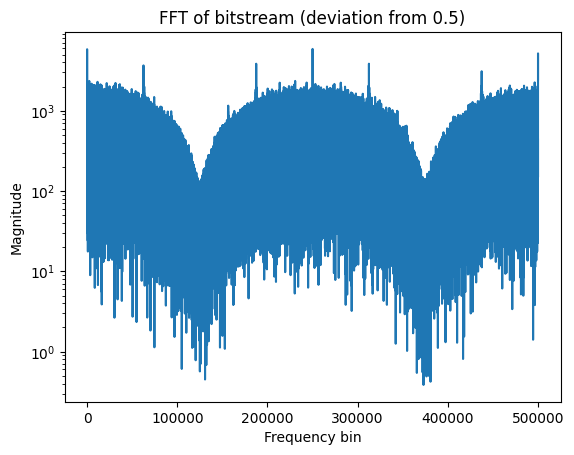

In [606]:
import matplotlib.pyplot as plt

fft_vals = np.fft.fft(bits - 0.5)
plt.semilogy(np.abs(fft_vals[:len(fft_vals)//2]))
plt.title("FFT of bitstream (deviation from 0.5)")
plt.xlabel("Frequency bin")
plt.ylabel("Magnitude")
plt.show()


## 4) Quick tests & metrics

In [ ]:

import numpy as np
import math
import matplotlib.pyplot as plt

def freq_monobit(bits):
    n = bits.size
    ones = int(bits.sum())
    p_hat = ones / n
    s = abs(ones - (n - ones))
    z = s / math.sqrt(n)
    return {"n": n, "ones": ones, "p_hat": p_hat, "z": z}

def runs_test(bits):
    n = bits.size
    ones = bits.sum()
    zeros = n - ones
    if ones == 0 or zeros == 0:
        return {"n": n, "runs": 1, "p_value": 0.0, "note": "all bits equal"}
    runs = 1 + int(np.sum(bits[1:] != bits[:-1]))
    pi = ones / n
    exp_runs = 2 * n * pi * (1 - pi) + 1
    var_runs = (2 * n * pi * (1 - pi) * (2 * n * pi * (1 - pi) - 1)) / (n - 1)
    z = (runs - exp_runs) / math.sqrt(var_runs) if var_runs > 0 else float("inf")
    from math import erf, sqrt
    p_value = 2 * (1 - 0.5 * (1 + erf(abs(z)/sqrt(2))))
    return {"n": n, "runs": runs, "expected": exp_runs, "z": z, "p_value": p_value}

def autocorr(bits, max_lag=16):
    n = bits.size
    x = bits * 2 - 1
    res = {}
    for k in range(1, max_lag+1):
        a = np.dot(x[:-k], x[k:]) / (n - k)
        res[k] = float(a)
    return res

def shannon_entropy_per_bit(bits):
    if bits.size < 8:
        return float('nan'), None
    pad = (8 - bits.size % 8) % 8
    if pad:
        bits = np.concatenate([bits, np.zeros(pad, dtype=np.uint8)])
    bytes_ = np.packbits(bits, bitorder="big")
    counts = np.bincount(bytes_, minlength=256).astype(np.float64)
    probs = counts / counts.sum()
    nz = probs[probs > 0]
    H_bytes = -np.sum(nz * np.log2(nz))
    return float(H_bytes / 8.0), counts

def min_entropy_bit(bits):
    p_hat = bits.mean()
    p_max = max(p_hat, 1 - p_hat)
    Hmin = -math.log2(p_max) if p_max > 0 else 0.0
    return Hmin

freq = freq_monobit(bits)
runs = runs_test(bits)
ac = autocorr(bits, max_lag=16)
Hperbit, byte_counts = shannon_entropy_per_bit(bits)
Hmin = min_entropy_bit(bits)

print("Frequency (monobit):", freq)
print("Runs test:", runs)
print("Autocorr (first 8 lags):", {k: round(v,4) for k,v in list(ac.items())[:8]})
print(f"Shannon entropy/bit (via bytes): {Hperbit:.5f}")
print(f"Min-entropy/bit (most common bit): {Hmin:.5f}")

plt.figure()
plt.title("Byte histogram (first 64 bins) - TRNG Approach A")
plt.bar(np.arange(64), byte_counts[:64])
plt.xlabel("Byte value (0..63)")
plt.ylabel("Count")
plt.show()

plt.figure()
plt.title("Autocorrelation vs lag - TRNG Approach A")
plt.plot(list(ac.keys()), list(ac.values()))
plt.xlabel("Lag (bits)")
plt.ylabel("Autocorr")
plt.grid(True)
plt.show()


## 5) Save a one-page text report (quick summary)

In [ ]:

report = f"""TRNG Approach A - RTC vs TCC jitter (XMEGA CW303)
Bits collected: {bits.size}

Frequency (monobit):
  ones = {freq['ones']}, p_hat = {freq['p_hat']:.6f}, z = {freq['z']:.3f}

Runs test:
  runs = {runs.get('runs')}, expected = {runs.get('expected', float('nan')):.2f},
  z = {runs.get('z', float('nan')):.3f}, p = {runs.get('p_value', float('nan')):.4f}

Entropy:
  Shannon entropy/bit (via bytes) = {Hperbit:.6f}
  Min-entropy/bit (bit MCV)       = {Hmin:.6f}

Notes:
  - This is a quick sanity battery; not a replacement for full NIST STS.
  - Duplicate this notebook for other approaches (ADC noise, RO, SRAM) and re-run.
"""

path = f"/mnt/data/{SAVE_PREFIX}_summary.txt"
with open(path, "w") as f:
    f.write(report)
print(report)
print("Saved report:", path)


## 6) Cleanup / disconnect (optional)

In [612]:

try:
    target.dis()
except Exception:
    pass
try:
    scope.dis()
except Exception:
    pass
print("Disconnected.")


Disconnected.
